## Fine Tune Parameter Trough CV

Hyperparam tuning: 100%|██████████| 9/9 [01:02<00:00,  6.96s/it]



Top 5 hyperparameter settings by CV-estimated cost:
 max_depth  n_estimators  avg_cost
      20.0           500  0.078360
      20.0           200  0.079006
      20.0           600  0.079327
       NaN           500  0.079649
       NaN           200  0.079971

Best params: {'n_estimators': 500, 'max_depth': 20}
Best CV-estimated cost: 0.0784

Optimal threshold across folds = 0.63


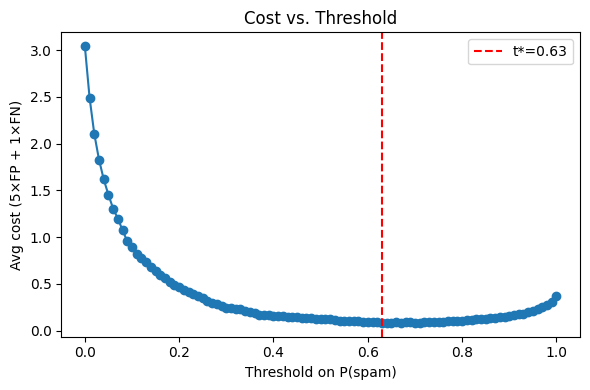

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, ParameterGrid, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# 1. Load & prepare data
df = pd.read_csv('../data/train.csv')
X = df.drop('response', axis=1).values
y = df['response'].map({1: 0, 2: 1}).values  # 0=non-spam, 1=spam


# 2. Define cost function
def compute_cost(y_true, p_spam, thresh):
    preds = (p_spam >= thresh).astype(int)
    fp = ((preds == 1) & (y_true == 0)).sum()
    fn = ((preds == 0) & (y_true == 1)).sum()
    return (5 * fp + fn) / len(y_true)

# 3. CV and parameter grid setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'n_estimators':     [200, 500, 600],
    'min_samples_leaf': [1, 5, 10],
    'max_depth':        [None, 10, 20],
    'max_features':     ['sqrt', 'log2', 0.3]
}
grid = list(ParameterGrid(param_grid))

# 4. Manual grid search with progress bar
thresholds = np.linspace(0, 1, 51)
results = []

for params in tqdm(grid, desc="Hyperparam tuning"):
    fold_costs = []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        p_spam = rf.predict_proba(X_val)[:, 1]
        # find best threshold cost on this fold
        costs = [compute_cost(y_val, p_spam, t) for t in thresholds]
        fold_costs.append(min(costs))
    avg_cost = np.mean(fold_costs)
    results.append({**params, 'avg_cost': avg_cost})

# 5. Summarize results
results_df = pd.DataFrame(results).sort_values('avg_cost').reset_index(drop=True)
print("\nTop 5 hyperparameter settings by CV-estimated cost:")
print(results_df.head(5).to_string(index=False))

best_params = results_df.loc[0, list(param_grid.keys())].to_dict()
# --------- FIX NaNs and floats ---------
best_params = {
    k: (None if pd.isna(v) else int(v) if k in ['n_estimators', 'min_samples_leaf', 'max_depth'] else v)
    for k, v in best_params.items()
}
# ---------------------------------------
print(f"\nBest params: {best_params}")
print(f"Best CV-estimated cost: {results_df.loc[0,'avg_cost']:.4f}")

Optimal threshold = 0.63, CV cost = 0.0842


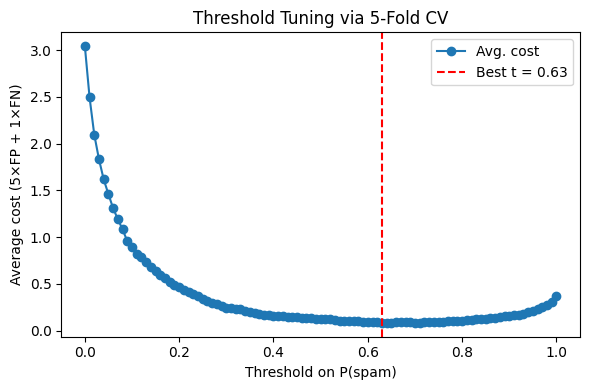


5-Fold CV Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1886
           1       0.98      0.88      0.93      1215

    accuracy                           0.95      3101
   macro avg       0.95      0.93      0.94      3101
weighted avg       0.95      0.95      0.94      3101



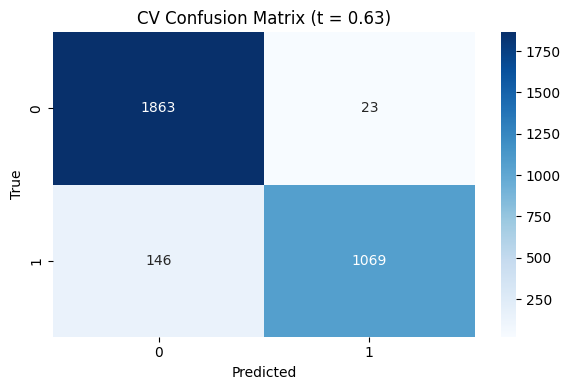


Predictions saved to '../prediction/predicted_RF.txt'.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load & Prepare the Data
filtered_train_df = pd.read_csv('../data/train.csv')  # 57 features + “response” (1=non-spam, 2=spam)
X = filtered_train_df.drop('response', axis=1)
y = filtered_train_df['response'].map({1: 0, 2: 1})             # {0: non-spam, 1: spam}

# 3. Set up 5-Fold CV and initial RF model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# 4. Obtain out-of-fold spam probabilities
#    cross_val_predict returns, for each sample, the probas from the fold where it was held out
p_spam_oof = cross_val_predict(
    rf, X, y,
    cv=cv,
    method='predict_proba'
)[:, 1]

# 5. Tune Decision Threshold on OOF predictions
def compute_cost(y_true, p_spam, thresh):
    """
    Computes average misclassification cost:
      FP cost = 5 (non-spam predicted as spam)
      FN cost = 1 (spam predicted as non-spam)
    """
    preds = (p_spam >= thresh).astype(int)
    fp = ((preds == 1) & (y_true == 0)).sum()
    fn = ((preds == 0) & (y_true == 1)).sum()
    return (5 * fp + 1 * fn) / len(y_true)

thresholds = np.linspace(0, 1, 101)
costs = [compute_cost(y.values, p_spam_oof, t) for t in thresholds]
best_idx = np.argmin(costs)
best_thresh = thresholds[best_idx]
print(f"Optimal threshold = {best_thresh:.2f}, CV cost = {costs[best_idx]:.4f}")

# 6. Visualize cost vs. threshold
plt.figure(figsize=(6,4))
plt.plot(thresholds, costs, marker='o', label='Avg. cost')
plt.axvline(best_thresh, color='red', linestyle='--', label=f"Best t = {best_thresh:.2f}")
plt.xlabel("Threshold on P(spam)")
plt.ylabel("Average cost (5×FP + 1×FN)")
plt.title("Threshold Tuning via 5-Fold CV")
plt.legend()
plt.tight_layout()
plt.show()

# 7. Evaluate OOF performance at best_thresh
y_oof_pred = (p_spam_oof >= best_thresh).astype(int)
print("\n5-Fold CV Classification Report:")
print(classification_report(y, y_oof_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y, y_oof_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"CV Confusion Matrix (t = {best_thresh:.2f})")
plt.tight_layout()
plt.show()

# 8. Retrain on Full Labeled Data
rf_full = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf_full.fit(X, y)

# 9. Predict on Unlabeled Test Data
test_df = pd.read_csv('../data/test.csv')  # same 57 features, no response
p_spam_test = rf_full.predict_proba(test_df)[:, 1]
y_pred_test = (p_spam_test >= best_thresh).astype(int)

# Map back to original labels {1: non-spam, 2: spam}
response_pred = pd.Series(y_pred_test).map({0: 1, 1: 2})

# 10. Save Final Predictions
response_pred.to_csv(
    '../prediction/predicted_RF.txt',
    sep='\t',
    index=False,
    header=False
)
print("\nPredictions saved to '../prediction/predicted_RF.txt'.")
